# PROSTATE MACHINE LEARNING <br>
step:
*   Import dataset
*   label encoding
*   Data splitting 80% 20%
*   Data normalization min max
*   FS2 (LR-Lasso and Random Forest)
*   5 Biomarker model training (5-CV) : (LR-LR, RF-Random Forest, RF-XGBoost, RF-Neural Network)
*   External validation with 5% (LR, RF, XGBoost, NN)
*   Pathway Analysis







# Import dataset

In [ ]:
import pandas as pd

rna = pd.read_csv("596_RNAmatrix.tsv", sep="\t")
sheet = pd.read_csv("samplesheet.tsv", sep="\t")


In [ ]:
rna

,PPP5C,PSMC4,NSUN2,SEC61A2,RRAGB,STRN4,HOMER2,AKT2,PRUNE2,TENT4A,...,ZXDA,ZXDB,CHIC1,JPX,FTX,ZNF585B,ZNF260,ZNF225,ZNF234,PTOV1-AS1
0,10.217433,10.892011,10.764008,8.086177,8.284940,11.049385,12.521871,11.179877,12.028402,8.818706,...,6.827586,8.693187,8.392965,8.842550,10.025969,7.896644,9.159700,6.519995,6.751049,7.855551
1,10.377779,11.351635,10.217126,8.173544,9.204712,11.018508,11.941439,11.479496,11.097688,8.447079,...,6.254232,8.065317,7.588616,8.756382,9.407880,7.975135,8.562148,6.400688,6.827370,8.676903
2,10.696659,11.302865,10.406636,7.709796,8.531338,11.317314,12.275989,11.456222,12.140479,8.431624,...,6.667442,8.240317,8.233366,8.567713,9.706918,8.476467,8.857141,7.078470,7.226035,8.388472
3,10.211635,11.273275,10.396608,8.242036,8.725181,11.082314,11.960114,11.820012,10.821414,8.896989,...,6.572094,8.045937,7.542778,8.151569,9.239979,7.371037,8.349528,6.291772,6.751314,8.289089
4,10.322802,10.769079,10.289901,8.170423,8.632439,11.030789,12.325524,11.519839,10.970186,8.898647,...,6.790196,8.351455,8.390939,9.004244,10.737848,8.530063,8.960634,7.481751,7.973136,8.466805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,9.682272,10.289631,10.312682,8.991794,9.920990,8.830769,13.325137,10.997602,12.890850,10.741442,...,9.352230,10.881638,9.699864,11.271056,12.924908,9.880423,9.768165,7.967604,8.325996,8.685253
592,10.084161,10.947362,10.621806,7.816751,8.442580,11.049746,12.133837,11.438902,11.122133,8.506886,...,7.106947,8.853999,8.224316,8.506886,9.590503,8.347443,9.890513,7.024853,7.159181,7.658078
593,10.308241,10.653146,10.773054,8.385387,8.258157,11.389410,11.844033,11.484630,11.262147,9.091902,...,6.820468,8.405001,8.195710,9.063391,10.426483,8.206928,9.277104,6.914908,7.677208,8.405001
594,10.712559,11.028111,10.580842,8.328869,8.905668,11.458211,10.862751,11.884749,10.654921,9.215811,...,7.335277,8.687947,8.141529,8.826479,9.846003,8.547781,8.809485,7.033348,7.443499,8.773290


In [ ]:
sheet

,Sample_ID,class
0,TCGA-KK-A6E6-nonMT,Non-metastasis
1,TCGA-KK-A6E3-nonMT,Non-metastasis
2,TCGA-G9-7519-nonMT,Non-metastasis
3,TCGA-HC-A6AS-nonMT,Non-metastasis
4,TCGA-HC-8260-nonMT,Non-metastasis
...,...,...
591,DTB-121-MT,Metastasis
592,TCGA-EJ-5499-nonMT,Non-metastasis
593,TCGA-YL-A8SF-nonMT,Non-metastasis
594,TCGA-HC-7080-nonMT,Non-metastasis


# Data Labeling

In [ ]:
sheet["label"] = sheet["class"].map({"Non-metastasis": 0, "Metastasis": 1})
sheet


,Sample_ID,class,label
0,TCGA-KK-A6E6-nonMT,Non-metastasis,0
1,TCGA-KK-A6E3-nonMT,Non-metastasis,0
2,TCGA-G9-7519-nonMT,Non-metastasis,0
3,TCGA-HC-A6AS-nonMT,Non-metastasis,0
4,TCGA-HC-8260-nonMT,Non-metastasis,0
...,...,...,...
591,DTB-121-MT,Metastasis,1
592,TCGA-EJ-5499-nonMT,Non-metastasis,0
593,TCGA-YL-A8SF-nonMT,Non-metastasis,0
594,TCGA-HC-7080-nonMT,Non-metastasis,0


# Data splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = rna  # Features (gene expression matrix)
y = sheet["label"]  # Labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
X_test

,PPP5C,PSMC4,NSUN2,SEC61A2,RRAGB,STRN4,HOMER2,AKT2,PRUNE2,TENT4A,...,ZXDA,ZXDB,CHIC1,JPX,FTX,ZNF585B,ZNF260,ZNF225,ZNF234,PTOV1-AS1
88,10.058679,10.431144,10.561338,7.388504,8.259892,10.946750,13.005194,11.474045,12.945110,8.870025,...,7.637537,8.962387,8.773342,8.995338,10.217024,8.667559,9.445339,7.087160,7.751637,7.739397
584,9.305909,10.325076,10.138940,9.590514,7.479627,9.733822,11.747918,10.999758,12.584540,10.312082,...,8.079808,12.850258,9.238826,11.185770,13.002590,11.318388,11.363169,8.110165,7.383409,7.847261
189,10.561025,11.108156,10.865628,8.050814,8.368762,11.335131,12.032618,11.692814,10.850291,9.015172,...,6.417508,8.209546,8.188348,8.989148,10.107445,8.387482,9.179143,7.042939,7.928289,8.360664
20,10.102012,11.656493,10.381881,9.093145,8.014803,11.030885,12.589906,11.011576,11.053090,9.027366,...,6.015121,7.968797,7.471242,8.878973,9.295643,7.975460,8.948322,5.988803,6.400984,8.588780
295,9.968031,10.353344,10.138650,7.567261,8.411400,11.016396,12.574945,11.658071,12.624166,8.955318,...,7.310526,9.007785,8.611842,8.678098,10.594710,8.189469,9.101536,7.394993,7.695724,8.011726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,9.577077,9.173255,10.631840,9.542203,9.637069,8.906983,13.127705,10.223452,15.816928,10.242888,...,9.353935,11.702980,8.564796,10.242888,12.260533,8.913063,9.449048,7.630792,7.947644,7.797911
363,10.519748,11.453938,10.603994,8.398271,8.733667,11.825673,11.739792,11.691856,11.647746,9.208840,...,6.629662,8.173811,8.217664,8.501854,9.810439,7.912693,8.862281,6.743451,7.298913,7.988307
257,10.310426,10.878504,10.194054,8.313652,8.797699,10.854990,11.912801,11.678831,11.240952,8.896228,...,6.502177,8.142867,7.966760,9.002793,9.945112,8.428589,9.058761,6.726830,7.070350,8.381075
252,10.367046,10.708887,10.587123,8.108799,8.248850,11.250445,12.060980,11.599553,11.007526,9.378305,...,6.660052,8.224052,8.290391,8.596669,9.868784,8.120364,8.697887,6.670610,7.416641,8.081448


In [ ]:
test_sheet = sheet[sheet.index.isin(X_test.index)]
test_sheet

,Sample_ID,class,label
1,TCGA-KK-A6E3-nonMT,Non-metastasis,0
13,TCGA-J4-A67N-nonMT,Non-metastasis,0
20,TCGA-EJ-A46F-nonMT,Non-metastasis,0
21,TCGA-CH-5754-nonMT,Non-metastasis,0
34,TCGA-VP-A879-nonMT,Non-metastasis,0
...,...,...,...
576,DTB-128-MT,Metastasis,1
584,DTB-083-MT,Metastasis,1
588,DTB-102-MT,Metastasis,1
592,TCGA-EJ-5499-nonMT,Non-metastasis,0


In [ ]:
sheet

,Sample_ID,class,label
0,TCGA-KK-A6E6-nonMT,Non-metastasis,0
1,TCGA-KK-A6E3-nonMT,Non-metastasis,0
2,TCGA-G9-7519-nonMT,Non-metastasis,0
3,TCGA-HC-A6AS-nonMT,Non-metastasis,0
4,TCGA-HC-8260-nonMT,Non-metastasis,0
...,...,...,...
591,DTB-121-MT,Metastasis,1
592,TCGA-EJ-5499-nonMT,Non-metastasis,0
593,TCGA-YL-A8SF-nonMT,Non-metastasis,0
594,TCGA-HC-7080-nonMT,Non-metastasis,0


In [ ]:
def sheet_features(sheet, features):
  # Step 1: Filter Sample_ID based on X_test's index
  sample_ids = sheet.loc[features.index, ["Sample_ID"]]

  # Step 2: Select the desired features from X_test
  selected_features = features[["MYH11", "PRMT1", "TENT4A"]]

  # Step 3: Concatenate column-wise (cbind)
  selected_set = pd.concat([sample_ids, selected_features], axis=1)
  return selected_set


In [ ]:
predict_set = sheet_features(sheet, X_test)
train_set = sheet_features(sheet, X_train)

In [ ]:
predict_set

,Sample_ID,MYH11,PRMT1,TENT4A
88,TCGA-EJ-7781-nonMT,16.425486,10.394562,8.870025
584,DTB-083-MT,12.043522,8.612378,10.312082
189,TCGA-KK-A7B1-nonMT,16.351638,11.555936,9.015172
20,TCGA-EJ-A46F-nonMT,12.106297,12.441793,9.027366
295,TCGA-CH-5745-nonMT,16.007885,11.109117,8.955318
...,...,...,...,...
525,DTB-149-MT,9.183350,9.419459,10.242888
363,TCGA-V1-A8WW-nonMT,14.749504,11.544738,9.208840
257,TCGA-V1-A9Z8-nonMT,16.814468,11.305984,8.896228
252,TCGA-KK-A8I4-nonMT,16.379562,11.355667,9.378305


In [ ]:
train_set

,Sample_ID,MYH11,PRMT1,TENT4A
199,TCGA-CH-5739-nonMT,15.803992,10.578513,8.883252
84,TCGA-ZG-A9N3-nonMT,15.949009,11.517851,9.493795
17,TCGA-ZG-A9L1-nonMT,15.208729,11.704425,9.075053
126,TCGA-2A-A8VL-nonMT,16.300432,11.300132,8.927261
406,TCGA-YL-A8HM-nonMT,13.064729,11.117547,8.725123
...,...,...,...,...
436,TCGA-HC-8266-nonMT,16.240483,11.040162,9.204675
407,TCGA-J4-A6M7-nonMT,16.029084,11.701670,9.111091
234,TCGA-EJ-A8FS-nonMT,13.602453,10.921520,8.673849
465,TCGA-EJ-5525-nonMT,14.211050,10.599781,9.281906


In [ ]:
predict_set.to_csv("predict_set.csv", index=True)
train_set.to_csv("train_set.csv", index=True)

# Data normalization min max

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
import pickle

# Replace this with your actual scaler object
# Example: scaler = StandardScaler().fit(X_train)

# Save the scaler to a file
with open("minmaxscaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


# Features selection 2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def cross_validate_model(X_train_scaled, y_train, model_type="lr", folds=5):
    """Performs k-fold cross-validation and collects classification metrics + feature importance."""

    if model_type == "lr":
        model = LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=42)
    elif model_type == "rf":
        model = RandomForestClassifier(random_state=42)
    else:
        raise ValueError("model_type must be 'lr' or 'rf'")

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    metrics = {"recall": [], "precision": [], "f1-score": [], "accuracy": [], "specificity": []}
    feature_importances = []

    for idx, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), start=1):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        print(f"Fold {idx}/{folds}")

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        report = classification_report(y_val, y_pred, output_dict=True)
        cm = confusion_matrix(y_val, y_pred)

        # Extract metrics for class 0, class 1, weighted avg
        for metric in ["recall", "precision", "f1-score"]:
            class0 = report["0"][metric]
            class1 = report["1"][metric]
            avg = report["weighted avg"][metric]
            metrics[metric].append([class0, class1, avg])

        # Accuracy
        acc = accuracy_score(y_val, y_pred)
        metrics["accuracy"].append(acc)

        # Specificity = TN / (TN + FP)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
            metrics["specificity"].append(specificity)
        else:
            metrics["specificity"].append(np.nan)

        # Feature importance
        if model_type == "lr":
            importance = np.abs(model.coef_).flatten()
        else:
            importance = np.abs(model.feature_importances_)

        feature_importances.append(importance)

    return metrics, np.array(feature_importances)

def display_performance_matrix(metrics):
    """Displays avg and stdev for Class 1 and single-value metrics like accuracy/specificity."""
    summary = {}

    for metric_name, values in metrics.items():
        label = metric_name.lower()
        if isinstance(values[0], list):  # For recall, precision, f1-score
            values_arr = np.array(values)  # shape: (folds, 3)
            class1_vals = values_arr[:, 1]  # class 1 column
            summary[label.capitalize()] = [
                np.mean(class1_vals),
                np.std(class1_vals)
            ]
        else:  # For accuracy and specificity
            val_arr = np.array(values)
            summary[label.capitalize()] = [
                np.mean(val_arr),
                np.std(val_arr)
            ]

    # Display nicely
    df_summary = pd.DataFrame.from_dict(summary, orient='index', columns=["avg", "stdev"])
    print("\nPerformance Summary (Class 1 where applicable):")
    print(df_summary.round(4))


def harvest_feature_importance(X_train, feature_importances):
    """Formats feature importance into a DataFrame with correct feature names."""
    feature_df = pd.DataFrame(
        feature_importances.T,
        columns=[f"CV{i+1}" for i in range(feature_importances.shape[0])],
        index=X_train.columns
    )
    feature_df["Avg"] = feature_df.mean(axis=1)
    return feature_df


## 1) LR-Lasso  

In [ ]:

# Example (assuming you have X_train_scaled as NumPy array and y_train as a Pandas Series):
metrics, feat_importance = cross_validate_model(X_train_scaled, y_train, model_type="lr", folds=5)
display_performance_matrix(metrics)


Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

Performance Summary (Class 1 where applicable):
             avg  stdev
Recall       1.0    0.0
Precision    1.0    0.0
F1-score     1.0    0.0
Accuracy     1.0    0.0
Specificity  1.0    0.0


In [ ]:
feature_df1 = harvest_feature_importance(X_train, feature_importances1)
feature_df1["Std"] = feature_df1.iloc[:, :-2].std(axis=1)  # Compute standard deviation correctly

# Reorder columns to move "Std" after "Avg"
feature_df1 = feature_df1[[col for col in feature_df1.columns if col not in ["Avg", "Std"]] + ["Avg", "Std"]]

# Sort by "Avg" in descending order
feature_df1 = feature_df1.sort_values(by="Avg", ascending=False)

feature_df1


,CV1,CV2,CV3,CV4,CV5,Avg,Std
MYH11,6.423377,5.903639,5.127202,5.281999,5.809642,5.709172,0.596252
PRMT1,4.259685,3.627382,4.340031,3.687639,5.077802,4.198508,0.373119
TENT4A,3.934763,3.192486,4.098295,5.008275,4.159083,4.078580,0.745866
ZNF585B,1.949914,1.901872,2.615755,2.132615,1.786952,2.077422,0.326002
STRN4,0.892695,2.270441,2.058537,2.597093,0.818214,1.727396,0.741844
FTX,2.013200,1.222929,1.834310,0.947718,1.842201,1.572072,0.502274
ZXDA,0.883543,2.860247,0.693624,1.273149,1.240188,1.390150,0.985064
AKT2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SEC61A2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
RRAGB,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


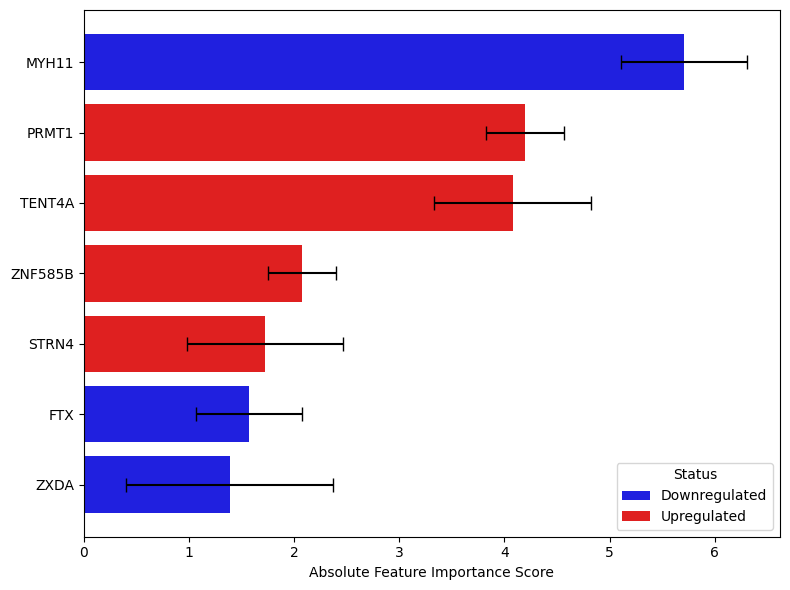

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare your data
data = {
    "Feature": ["MYH11", "PRMT1", "TENT4A", "ZNF585B", "STRN4", "FTX", "ZXDA"],
    "Importance": [5.709172, 4.198508, 4.078580, 2.077422, 1.727396, 1.572072, 1.390150],
    "Stdev": [0.596252, 0.373119, 0.745866, 0.326002, 0.741844, 0.502274, 0.985064],
    "Status": ["Downregulated", "Upregulated", "Upregulated", "Upregulated",
               "Upregulated", "Downregulated", "Downregulated"]
}

df = pd.DataFrame(data)

# Set color based on status
palette = {"Upregulated": "red", "Downregulated": "blue"}

# Create the horizontal bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df,
    y="Feature",
    x="Importance",
    hue="Status",
    palette=palette,
    dodge=False,
    errorbar=None  # Avoid deprecated ci
)

# Add standard deviation error bars manually
for i, row in df.iterrows():
    ax.errorbar(row["Importance"], i, xerr=row["Stdev"], fmt='none', c='black', capsize=5)

# Customizations
plt.xlabel("Absolute Feature Importance Score")
plt.ylabel("")
#plt.title("Feature Importance with Regulation Status")
plt.legend(title="Status", loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
feature_df1.to_excel("feature_importance_LR.xlsx", index=True)


## RF

In [ ]:
metrics2, feature_importances2 = cross_validate_model(X_train_scaled, y_train, model_type="rf")  # or "rf"
display_performance_matrix(metrics2)

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

Performance Summary (Class 1 where applicable):
                avg   stdev
Recall       1.0000  0.0000
Precision    0.9882  0.0235
F1-score     0.9939  0.0121
Accuracy     0.9979  0.0042
Specificity  0.9975  0.0051


In [ ]:
feature_df2 = harvest_feature_importance(X_train, feature_importances2)
feature_df2["Std"] = feature_df2.iloc[:, :-2].std(axis=1)  # Compute standard deviation correctly

# Reorder columns to move "Std" after "Avg"
feature_df2 = feature_df2[[col for col in feature_df2.columns if col not in ["Avg", "Std"]] + ["Avg", "Std"]]

# Sort by "Avg" in descending order
feature_df2 = feature_df2.sort_values(by="Avg", ascending=False)

feature_df2


,CV1,CV2,CV3,CV4,CV5,Avg,Std
PRMT1,0.100691,0.138882,0.102184,0.109876,0.122121,0.114751,0.017777
STRN4,0.103744,0.119073,0.106158,0.118412,0.114077,0.112293,0.008028
FTX,0.119853,0.090014,0.114516,0.086156,0.091394,0.100387,0.017014
ZXDB,0.103286,0.088770,0.101176,0.101429,0.098101,0.098552,0.006664
TENT4A,0.056987,0.082622,0.093330,0.143652,0.080771,0.091472,0.036355
ZNF585B,0.063385,0.071975,0.069511,0.034090,0.057312,0.059255,0.017477
JPX,0.066451,0.049434,0.063191,0.045861,0.068771,0.058742,0.010110
ZXDA,0.066584,0.055302,0.044212,0.043994,0.053432,0.052705,0.010759
SEC61A2,0.060687,0.041643,0.051480,0.061338,0.040169,0.051063,0.009263
MYH11,0.044137,0.046151,0.041931,0.045077,0.054811,0.046421,0.001795


<ipython-input-401-471689411>:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x="Metric", y="Avg_pct", hue="Model", ci=None)


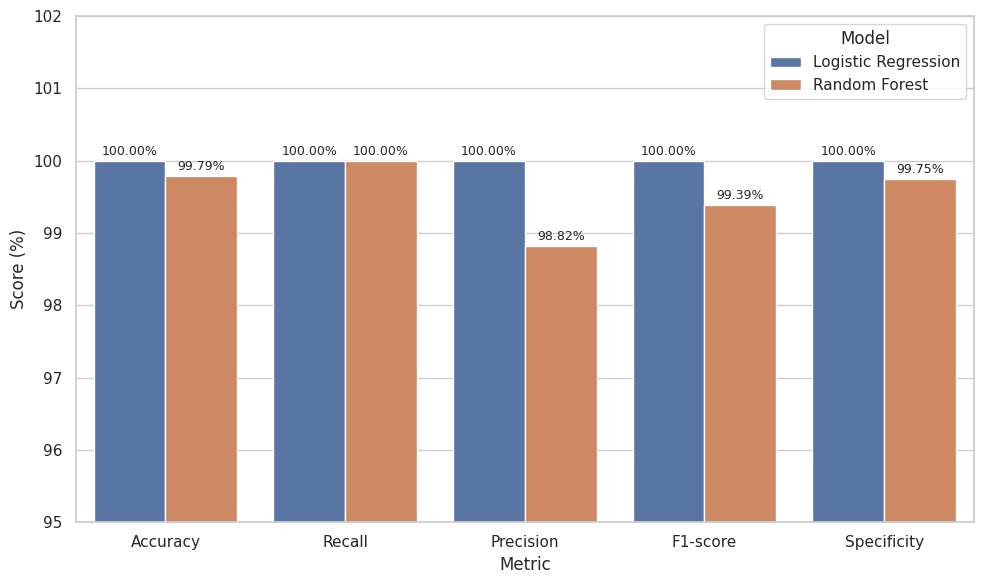

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data input
data = {
    "Metric": ["Accuracy", "Recall", "Precision", "F1-score", "Specificity"] * 2,
    "Model": ["Logistic Regression"] * 5 + ["Random Forest"] * 5,
    "Avg": [1.0, 1.0, 1.0, 1.0, 1.0, 0.9979, 1.0000, 0.9882, 0.9939, 0.9975],
    "Stdev": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0042, 0.0000, 0.0235, 0.0121, 0.0051]
}

df = pd.DataFrame(data)
df["Avg_pct"] = df["Avg"] * 100

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
ax = sns.barplot(data=df, x="Metric", y="Avg_pct", hue="Model", ci=None)

# Set y-axis from 95 to 100
plt.ylim(95, 102)
plt.ylabel("Score (%)")
#plt.title("Model Performance Metrics")

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=9, padding=2)

plt.legend(title="Model")
plt.tight_layout()
plt.show()


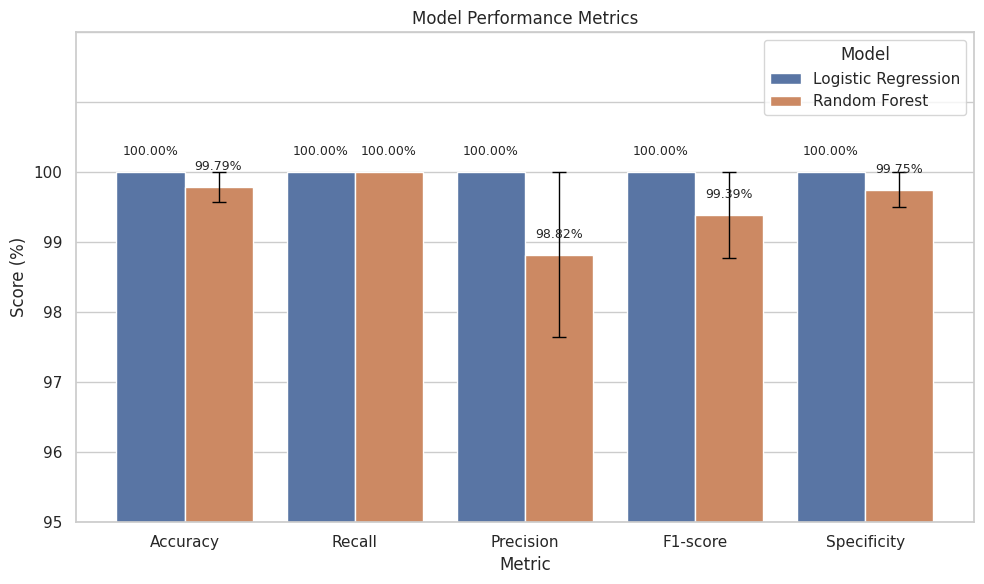

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data input
data = {
    "Metric": ["Accuracy", "Recall", "Precision", "F1-score", "Specificity"] * 2,
    "Model": ["Logistic Regression"] * 5 + ["Random Forest"] * 5,
    "Avg": [1.0, 1.0, 1.0, 1.0, 1.0, 0.9979, 1.0000, 0.9882, 0.9939, 0.9975],
    "Stdev": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0042, 0.0000, 0.0235, 0.0121, 0.0051]
}

df = pd.DataFrame(data)
df["Avg_pct"] = df["Avg"] * 100
df["Stdev_pct"] = df["Stdev"] * 100
df["Stdev_capped"] = df.apply(lambda row: min(row["Stdev_pct"], 100 - row["Avg_pct"]), axis=1)

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

ax = sns.barplot(
    data=df,
    x="Metric",
    y="Avg_pct",
    hue="Model",
    errorbar=None
)

# Match bar patches to df rows
patch_index = 0
for model in df["Model"].unique():
    for metric in df["Metric"].unique():
        row = df[(df["Model"] == model) & (df["Metric"] == metric)].iloc[0]
        bar = ax.patches[patch_index]
        height = bar.get_height()
        err = row["Stdev_capped"]
        bar_x = bar.get_x() + bar.get_width() / 2
        if err > 0:
            ax.errorbar(bar_x, height, yerr=err, fmt='none', c='black', capsize=5, lw=1)
        if height <= 100:
            ax.text(
                bar_x,
                height + 0.2,
                f"{height:.2f}%",
                ha='center',
                va='bottom',
                fontsize=9
            )
        patch_index += 1

# Set y-axis from 95 to 102
plt.ylim(95, 102)
plt.ylabel("Score (%)")
plt.title("Model Performance Metrics")

# Remove y-tick labels > 100
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.set_yticklabels([f"{tick:.0f}" if tick <= 100 else "" for tick in ticks])

plt.legend(title="Model")
plt.tight_layout()
plt.show()


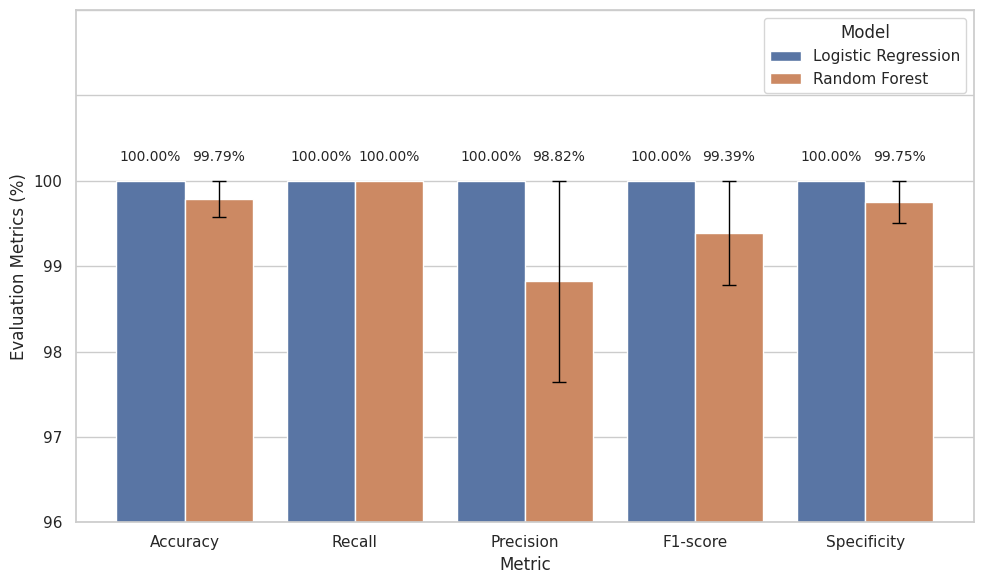

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data input
data = {
    "Metric": ["Accuracy", "Recall", "Precision", "F1-score", "Specificity"] * 2,
    "Model": ["Logistic Regression"] * 5 + ["Random Forest"] * 5,
    "Avg": [1.0, 1.0, 1.0, 1.0, 1.0, 0.9979, 1.0000, 0.9882, 0.9939, 0.9975],
    "Stdev": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0042, 0.0000, 0.0235, 0.0121, 0.0051]
}

df = pd.DataFrame(data)
df["Avg_pct"] = df["Avg"] * 100
df["Stdev_pct"] = df["Stdev"] * 100
df["Stdev_capped"] = df.apply(lambda row: min(row["Stdev_pct"], 100 - row["Avg_pct"]), axis=1)

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

ax = sns.barplot(
    data=df,
    x="Metric",
    y="Avg_pct",
    hue="Model",
    errorbar=None
)

# Match bar patches to df rows
patch_index = 0
for model in df["Model"].unique():
    for metric in df["Metric"].unique():
        row = df[(df["Model"] == model) & (df["Metric"] == metric)].iloc[0]
        bar = ax.patches[patch_index]
        height = bar.get_height()
        err = row["Stdev_capped"]
        bar_x = bar.get_x() + bar.get_width() / 2
        # Draw error bar
        if err > 0:
            ax.errorbar(bar_x, height, yerr=err, fmt='none', c='black', capsize=5, lw=1)
        # Add label above error bar
        label_y = height + err + 0.2  # dynamic spacing
        if height + err <= 100:
            ax.text(
                bar_x,
                label_y,
                f"{height:.2f}%",
                ha='center',
                va='bottom',
                fontsize=10
            )
        patch_index += 1

# Set y-axis from 95 to 102
plt.ylim(96, 102)
plt.ylabel("Evaluation Metrics (%)")
#plt.title("Model Performance Metrics")

# Remove y-tick labels > 100
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.set_yticklabels([f"{tick:.0f}" if tick <= 100 else "" for tick in ticks])

plt.legend(title="Model")
plt.tight_layout()
plt.show()


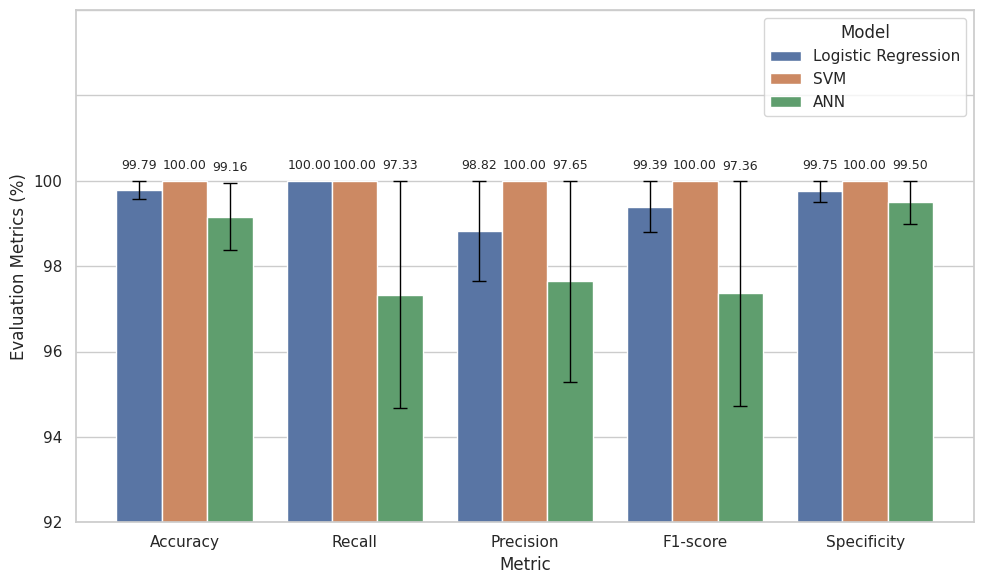

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correct data structure
data = [
    # Logistic Regression
    {"Model": "Logistic Regression", "Metric": "Accuracy", "Avg": 0.997917, "Stdev": 0.004167},
    {"Model": "Logistic Regression", "Metric": "Recall", "Avg": 1.000000, "Stdev": 0.000000},
    {"Model": "Logistic Regression", "Metric": "Precision", "Avg": 0.988235, "Stdev": 0.023529},
    {"Model": "Logistic Regression", "Metric": "F1-score", "Avg": 0.993939, "Stdev": 0.012121},
    {"Model": "Logistic Regression", "Metric": "Specificity", "Avg": 0.997500, "Stdev": 0.005000},

    # SVM
    {"Model": "SVM", "Metric": "Accuracy", "Avg": 1.0, "Stdev": 0.0},
    {"Model": "SVM", "Metric": "Recall", "Avg": 1.0, "Stdev": 0.0},
    {"Model": "SVM", "Metric": "Precision", "Avg": 1.0, "Stdev": 0.0},
    {"Model": "SVM", "Metric": "F1-score", "Avg": 1.0, "Stdev": 0.0},
    {"Model": "SVM", "Metric": "Specificity", "Avg": 1.0, "Stdev": 0.0},

    # ANN
    {"Model": "ANN", "Metric": "Accuracy", "Avg": 0.991601, "Stdev": 0.007871},
    {"Model": "ANN", "Metric": "Recall", "Avg": 0.973333, "Stdev": 0.053333},
    {"Model": "ANN", "Metric": "Precision", "Avg": 0.976471, "Stdev": 0.028818},
    {"Model": "ANN", "Metric": "F1-score", "Avg": 0.973593, "Stdev": 0.026275},
    {"Model": "ANN", "Metric": "Specificity", "Avg": 0.994968, "Stdev": 0.006163},
]

# Create DataFrame
df = pd.DataFrame(data)
df["Avg_pct"] = df["Avg"] * 100
df["Stdev_pct"] = df["Stdev"] * 100
df["Stdev_capped"] = df.apply(lambda row: min(row["Stdev_pct"], 100 - row["Avg_pct"]), axis=1)

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

ax = sns.barplot(
    data=df,
    x="Metric",
    y="Avg_pct",
    hue="Model",
    errorbar=None
)

# Match bar patches to df rows
patch_index = 0
for model in df["Model"].unique():
    for metric in df["Metric"].unique():
        row = df[(df["Model"] == model) & (df["Metric"] == metric)].iloc[0]
        bar = ax.patches[patch_index]
        height = bar.get_height()
        err = row["Stdev_capped"]
        bar_x = bar.get_x() + bar.get_width() / 2
        # Draw error bar
        if err > 0:
            ax.errorbar(bar_x, height, yerr=err, fmt='none', c='black', capsize=5, lw=1)
        # Add label above error bar
        label_y = height + err + 0.2
        if height + err <= 100:
            ax.text(bar_x, label_y, f"{height:.2f}", ha='center', va='bottom', fontsize=9)
        patch_index += 1

# Set y-axis
plt.ylim(92, 104)
plt.ylabel("Evaluation Metrics (%)")

# Remove y-tick labels > 100
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.set_yticklabels([f"{tick:.0f}" if tick <= 100 else "" for tick in ticks])

plt.legend(title="Model", loc="upper right")
plt.tight_layout()
plt.show()


# 3 biomarker model training

In [ ]:
biomarker = ['MYH11','PRMT1', 'TENT4A']
# biomarker5 = ['MYH11', 'PRMT1', 'TENT4A', 'STRN4', 'FTX']
X_train_scaled_biomarker = X_train_scaled[:, [rna.columns.get_loc(col) for col in biomarker]]
X_test_scaled_biomarker = X_test_scaled[:, [rna.columns.get_loc(col) for col in biomarker]]

In [ ]:
def cross_validate_model(X_train_scaled, y_train, models, folds=5):
    """Performs k-fold cross-validation and selects the best model based on F1-score."""

    # If a single model is provided, convert it to a dictionary
    if not isinstance(models, dict):
        models = {"Model": models}  # Wrap single model in a dictionary

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    best_model = None
    best_f1 = -1
    model_scores = {}
    best_metrics = None

    for model_name, model in models.items():
        print(f"Evaluating model: {model_name}")
        metrics = {"recall": [], "precision": [], "f1-score": []}

        for train_idx, val_idx in skf.split(X_train_scaled, y_train):
            X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            report = classification_report(y_val, y_pred, output_dict=True)

            # Store classification metrics
            for metric in metrics.keys():
                class0 = report["0"][metric]
                class1 = report["1"][metric]
                avg = report["weighted avg"][metric]
                metrics[metric].append([class0, class1, avg])

        # Compute average F1-score across folds
        avg_f1 = np.mean([x[2] for x in metrics["f1-score"]])  # Weighted avg F1-score
        model_scores[model_name] = avg_f1

        # Update best model
        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_model = model
            best_metrics = metrics  # Save metrics for best model

    print(f"Best Model: {best_model} with F1-score: {best_f1:.4f}")
    return best_model, best_metrics  # Return detailed metrics for best model


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

def cross_validate_model(X_train_scaled, y_train, models, folds=5):
    """Performs k-fold cross-validation and selects the best model based on F1-score."""

    if not isinstance(models, dict):
        models = {"Model": models}

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    best_model = None
    best_f1 = -1
    best_metrics_summary = None

    for model_name, model in models.items():
        print(f"Evaluating model: {model_name}")
        metrics = {
            "Accuracy": [],
            "Recall": [],
            "Precision": [],
            "F1-score": [],
            "Specificity": []
        }

        for train_idx, val_idx in skf.split(X_train_scaled, y_train):
            X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)

            # Classification report
            report = classification_report(y_val, y_pred, output_dict=True)
            cm = confusion_matrix(y_val, y_pred)

            TN, FP, FN, TP = cm.ravel()  # assumes binary classification, class 1 is positive

            accuracy = accuracy_score(y_val, y_pred)
            recall = report['1']['recall']
            precision = report['1']['precision']
            f1 = report['1']['f1-score']
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

            metrics["Accuracy"].append(accuracy)
            metrics["Recall"].append(recall)
            metrics["Precision"].append(precision)
            metrics["F1-score"].append(f1)
            metrics["Specificity"].append(specificity)

        # Compute average F1-score to select best model
        avg_f1 = np.mean(metrics["F1-score"])
        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_model = model
            best_metrics_summary = {
                metric: {"Avg": np.mean(values), "Stdev": np.std(values)}
                for metric, values in metrics.items()
            }

    # Convert to DataFrame
    df_summary = pd.DataFrame(best_metrics_summary).T
    print(f"\nBest Model: {best_model} with F1-score: {best_f1:.4f}\n")
    print(df_summary)

    return best_model, df_summary


## LR

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

best_lr, metrics_lr = cross_validate_model(X_train_scaled_biomarker, y_train, log_reg)

display_performance_matrix(metrics_lr)  # Now it gets detailed metrics


Evaluating model: Model

Best Model: LogisticRegression(max_iter=1000, random_state=42) with F1-score: 0.9939

                  Avg     Stdev
Accuracy     0.997917  0.004167
Recall       1.000000  0.000000
Precision    0.988235  0.023529
F1-score     0.993939  0.012121
Specificity  0.997500  0.005000

Performance Summary (Class 1 where applicable):
          avg   stdev
Avg    0.9955  0.0041
Stdev  0.0090  0.0083


/tmp/ipython-input-30-3195704007.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(values[0], list):  # For recall, precision, f1-score


## SVM

In [ ]:
# import svc
from sklearn.svm import SVC
svm_rbf = SVC(kernel="rbf", probability=True, random_state=42)
best_svm, metrics_svm = cross_validate_model(X_train_scaled_biomarker, y_train, svm_rbf)
display_performance_matrix(metrics_svm)

Evaluating model: Model

Best Model: SVC(probability=True, random_state=42) with F1-score: 1.0000

             Avg  Stdev
Accuracy     1.0    0.0
Recall       1.0    0.0
Precision    1.0    0.0
F1-score     1.0    0.0
Specificity  1.0    0.0

Performance Summary (Class 1 where applicable):
       avg  stdev
Avg    1.0    0.0
Stdev  0.0    0.0


/tmp/ipython-input-30-3195704007.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(values[0], list):  # For recall, precision, f1-score


In [ ]:
# import svc
from sklearn.svm import SVC
svm_rbf = SVC(kernel="rbf", probability=True, random_state=42)
best_svm, metrics_svm = cross_validate_model(X_train_scaled_biomarker, y_train, svm_rbf)
display_performance_matrix(metrics_svm)

Evaluating model: Model

Best Model: SVC(probability=True, random_state=42) with F1-score: 1.0000

             Avg  Stdev
Accuracy     1.0    0.0
Recall       1.0    0.0
Precision    1.0    0.0
F1-score     1.0    0.0
Specificity  1.0    0.0

Performance Summary (Class 1 where applicable):
       avg  stdev
Avg    1.0    0.0
Stdev  0.0    0.0


/tmp/ipython-input-30-3195704007.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(values[0], list):  # For recall, precision, f1-score


# Neural Network

In [ ]:
pip install scikeras

In [ ]:
from scikeras.wrappers import KerasClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define Neural Network Model
def build_nn_model():
    model = Sequential([
        Dense(3, activation="relu", input_shape=(3,)),
        Dense(3, activation="relu", input_shape=(5,)),
        Dense(1, activation="sigmoid")  # Output layer for binary classification
    ])

    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# Wrap TensorFlow model for compatibility with cross-validation
nn_model = KerasClassifier(model=build_nn_model, epochs=50, batch_size=8, verbose=0)

# Perform 5-fold cross-validation
#metrics_nn = cross_validate_model(X_train_scaled_biomarker, y_train, nn_model)

# Display performance matrix
#display_performance_matrix(metrics_nn)


In [ ]:
from scikeras.wrappers import KerasClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define Neural Network Model
def build_nn_model():
    model = Sequential([
        Dense(3, activation="relu", input_shape=(3,)),
        Dense(3, activation="relu", input_shape=(5,)),
        Dense(1, activation="sigmoid")  # Output layer for binary classification
    ])

    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# Wrap TensorFlow model for compatibility with cross-validation
nn_model = KerasClassifier(model=build_nn_model, epochs=50, batch_size=8, verbose=0)
best_nn, metrics_nn = cross_validate_model(X_train_scaled_biomarker, y_train, nn_model)
display_performance_matrix(metrics_nn)

Evaluating model: Model


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo


Best Model: KerasClassifier(
	model=<function build_nn_model at 0x7a5b9cc94f40>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=8
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=50
	class_weight=None
) with F1-score: 0.9939

                  Avg     Stdev
Accuracy     0.997917  0.004167
Recall       1.000000  0.000000
Precision    0.988235  0.023529
F1-score     0.993939  0.012121
Specificity  0.997500  0.005000

Performance Summary (Class 1 where applicable):
          avg   stdev
Avg    0.9955  0.0041
Stdev  0.0090  0.0083


/tmp/ipython-input-30-3195704007.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(values[0], list):  # For recall, precision, f1-score


# External Validation

In [ ]:
X_test_scaled_biomarker = X_test_scaled[:, [rna.columns.get_loc(col) for col in biomarker]]

In [ ]:
from sklearn.metrics import classification_report

def external_validation(model, X_test_scaled, y_test):
    """Evaluates the best model on an external test set and displays classification metrics."""

    # Predict on test data
    y_pred = model.predict(X_test_scaled)

    # Generate classification report
    report = classification_report(y_test, y_pred, output_dict=True)

    # Extract metrics for each class and weighted average
    metrics = {
        "Class 0": {
            "Precision": report["0"]["precision"],
            "Recall": report["0"]["recall"],
            "F1-score": report["0"]["f1-score"]
        },
        "Class 1": {
            "Precision": report["1"]["precision"],
            "Recall": report["1"]["recall"],
            "F1-score": report["1"]["f1-score"]
        },
        "Weighted Avg": {
            "Precision": report["weighted avg"]["precision"],
            "Recall": report["weighted avg"]["recall"],
            "F1-score": report["weighted avg"]["f1-score"]
        }
    }

    # Convert to DataFrame for better visualization
    metrics_df = pd.DataFrame(metrics).T
    print(metrics_df)

    return metrics_df  # Return the metrics for further analysis if needed


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

def external_validation(model, X_test_scaled, y_test):
    """Evaluates the best model on an external test set and displays classification metrics."""

    # Predict on test data
    y_pred = model.predict(X_test_scaled)

    # Generate classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()  # assumes binary classification with labels 0 and 1

    # Compute accuracy and specificity
    accuracy = accuracy_score(y_test, y_pred)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    # Extract metrics (focused on class 1)
    metrics = {
        "Class 1": {
            "Accuracy": accuracy,
            "Precision": report["1"]["precision"],
            "Recall": report["1"]["recall"],
            "F1-score": report["1"]["f1-score"],
            "Specificity": specificity
        }
    }

    # Convert to DataFrame for display
    metrics_df = pd.DataFrame(metrics).T
    print(metrics_df)

    return metrics_df


In [ ]:
# Perform external validation
metrics_test_lr = external_validation(best_lr, X_test_scaled_biomarker, y_test)

         Accuracy  Precision  Recall  F1-score  Specificity
Class 1  0.991667        1.0    0.95  0.974359          1.0


In [ ]:
# Perform external validation
metrics_test_svm = external_validation(best_svm, X_test_scaled_biomarker, y_test)

         Accuracy  Precision  Recall  F1-score  Specificity
Class 1  0.983333       0.95    0.95      0.95         0.99


In [ ]:
# Perform external validation
metrics_test_nn = external_validation(best_nn, X_test_scaled_biomarker, y_test)

         Accuracy  Precision  Recall  F1-score  Specificity
Class 1  0.991667        1.0    0.95  0.974359          1.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Refit scaler only on those 3 features from X_train
selected_features = ["MYH11", "PRMT1", "TENT4A"]
scaler_3 = MinMaxScaler()
scaler_3.fit(X_train[selected_features])


MinMaxScaler()

EXPLAINER

In [110]:
# Logistic Regression Explainer (fast)
explainer_lr = shap.Explainer(best_lr.predict_proba, X_train_scaled_biomarker)

# Neural Network (MLPClassifier) Explainer using KernelExplainer (model-agnostic, slower)
explainer_nn = shap.KernelExplainer(best_nn.predict_proba, X_train_scaled_biomarker)


In [114]:
# For binary classification, return only class-1 probability
explainer_nn = shap.KernelExplainer(lambda x: best_nn.predict_proba(x)[:, 1], X_train_scaled_biomarker)


In [142]:
def explain_n_predictions_scaled_auto(
    model,
    scaler,
    prediction_set,
    feature_cols,
    n=3,
    random_seed=42
):
    import shap
    import numpy as np
    import pandas as pd
    import random
    import matplotlib.pyplot as plt

    assert all(col in prediction_set.columns for col in feature_cols), "Missing feature columns."

    # Prepare inputs
    X_input = prediction_set[feature_cols]
    X_scaled = pd.DataFrame(scaler.transform(X_input), columns=feature_cols, index=prediction_set.index)

    # Random sample selection
    random.seed(random_seed)
    selected = X_scaled.sample(n=n, random_state=random_seed)

    # Predict function — now robust!
    def predict_fn(x):
        probs = model.predict_proba(x)
        probs = np.array(probs)
        if probs.ndim == 0:
            return np.array([1 - probs])  # flip
        elif probs.ndim == 1:
            return 1 - probs              # flip
        elif probs.ndim == 2:
            if probs.shape[1] == 1:
                return 1 - probs.flatten()  # flip
            else:
                return probs[:, 1]  # if class 1 is MT
        else:
            raise ValueError(f"Unexpected shape: {probs.shape}")


    # SHAP background
    background = X_scaled.sample(n=min(100, len(X_scaled)), random_state=random_seed)
    explainer = shap.KernelExplainer(predict_fn, shap.kmeans(background, 10))

    # SHAP waterfall for each selected sample
    for idx in selected.index:
        x = selected.loc[[idx]]
        shap_values = explainer.shap_values(x, nsamples=100)

        explanation = shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=x.iloc[0].values,
            feature_names=feature_cols
        )

        sample_id = prediction_set.loc[idx, "Sample_ID"] if "Sample_ID" in prediction_set.columns else idx
        pred_prob = predict_fn(x)[0]
        pred_label = int(pred_prob > 0.5)

        print(f"\nSample_ID: {sample_id} — Predicted Class: {pred_label} (p={pred_prob:.3f})")

        shap.plots.waterfall(explanation)
        plt.title(f"SHAP Waterfall — Sample {sample_id}")
        plt.tight_layout()
        plt.show()


In [154]:
print("Model classes:", best_nn.classes_)  # sanity check


Model classes: [0 1]


In [163]:
def make_predict_fn(model):
    def predict_fn(x):
        probs = model.predict_proba(x)
        probs = np.array(probs)

        if probs.ndim == 0:
            return np.array([1 - probs])  # flip
        elif probs.ndim == 1:
            return 1 - probs              # flip
        elif probs.ndim == 2:
            if probs.shape[1] == 1:
                return 1 - probs.flatten()  # flip
            else:
                return probs[:, 1]  # class 1 = Metastasis
        else:
            raise ValueError(f"Unexpected shape: {probs.shape}")
    return predict_fn




def explain_n_predictions_scaled_auto(
    scaler,
    explainer,
    predict_fn,
    prediction_set,
    feature_cols,
    n=3,
    random_seed=42
):
    import shap
    import numpy as np
    import pandas as pd
    import random
    import matplotlib.pyplot as plt

    assert all(col in prediction_set.columns for col in feature_cols), "Missing feature columns."

    X_input = prediction_set[feature_cols]
    X_scaled = pd.DataFrame(scaler.transform(X_input), columns=feature_cols, index=prediction_set.index)

    random.seed(random_seed)
    selected = X_scaled.sample(n=n, random_state=random_seed)

    for idx in selected.index:
        x = selected.loc[[idx]]
        shap_values = explainer.shap_values(x, nsamples=100)

        explanation = shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=x.iloc[0].values,
            feature_names=feature_cols
        )

        sample_id = prediction_set.loc[idx, "Sample_ID"] if "Sample_ID" in prediction_set.columns else idx
        pred_prob = predict_fn(x)[0]
        pred_label = int(pred_prob > 0.5)

        print(f"\nSample_ID: {sample_id} — Predicted Class: {pred_label} (p={pred_prob:.3f})")
        shap.plots.waterfall(explanation)
        plt.title(f"SHAP Waterfall — Sample {sample_id}")
        plt.tight_layout()
        plt.gcf().canvas.draw()  # ensures clean rendering
        plt.close()              # 🔥 closes the figure to prevent blank next plot




  0%|          | 0/1 [00:00<?, ?it/s]


Sample_ID: TCGA-ZG-A9ND-nonMT — Predicted Class: 0 (p=0.011)


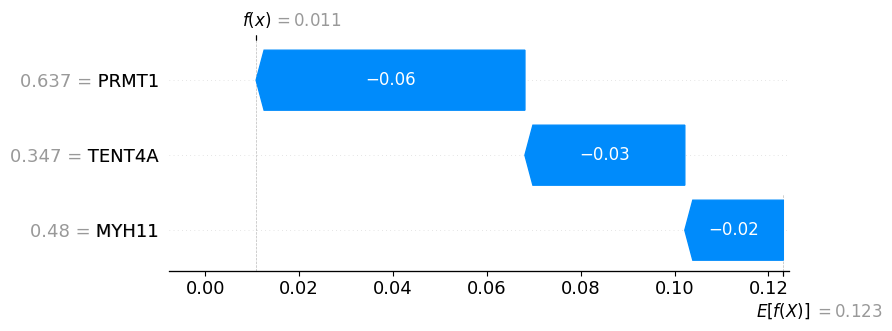

  0%|          | 0/1 [00:00<?, ?it/s]


Sample_ID: DTB-098-MT — Predicted Class: 1 (p=0.731)


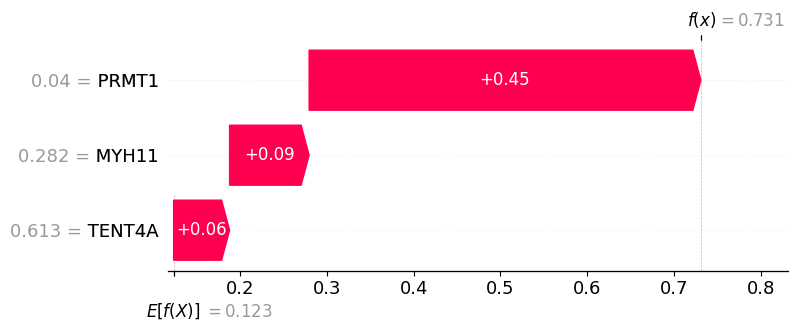

  0%|          | 0/1 [00:00<?, ?it/s]


Sample_ID: TCGA-YL-A9WH-nonMT — Predicted Class: 0 (p=0.005)


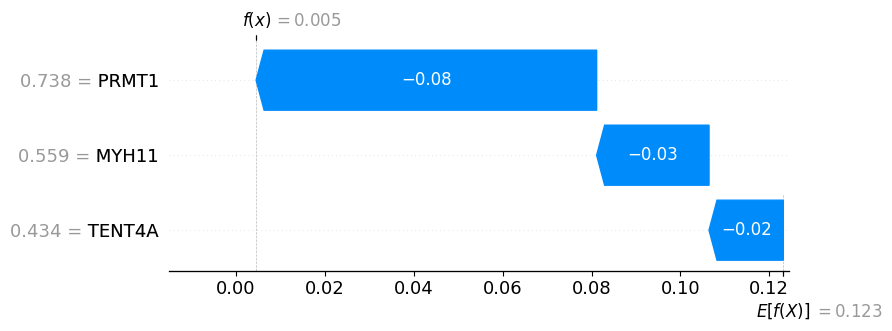

In [164]:
predict_fn_nn = make_predict_fn(best_nn)
X_background = X_train_scaled_biomarker.copy()
explainer_nn = shap.KernelExplainer(predict_fn_nn, shap.kmeans(X_background, 10))


explain_n_predictions_scaled_auto(
    scaler=scaler_3,
    explainer=explainer_nn,
    predict_fn=predict_fn_nn,
    prediction_set=predict_set,
    feature_cols=["MYH11", "PRMT1", "TENT4A"],
    n=3,
    random_seed=10000
)



  0%|          | 0/1 [00:00<?, ?it/s]


Sample_ID: TCGA-ZG-A9ND-nonMT — Predicted Class: 0 (p=0.095)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


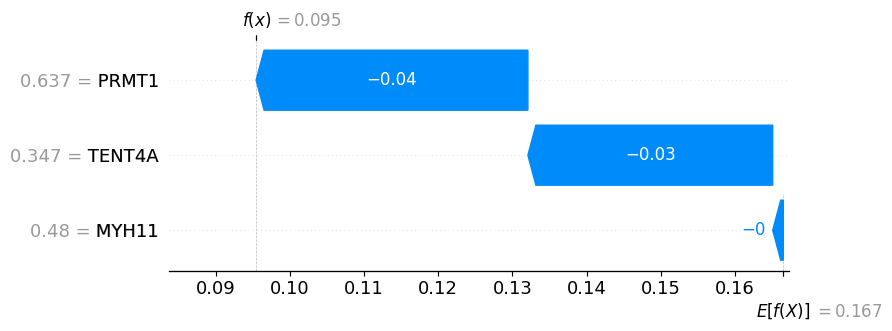

  0%|          | 0/1 [00:00<?, ?it/s]


Sample_ID: DTB-098-MT — Predicted Class: 1 (p=0.890)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


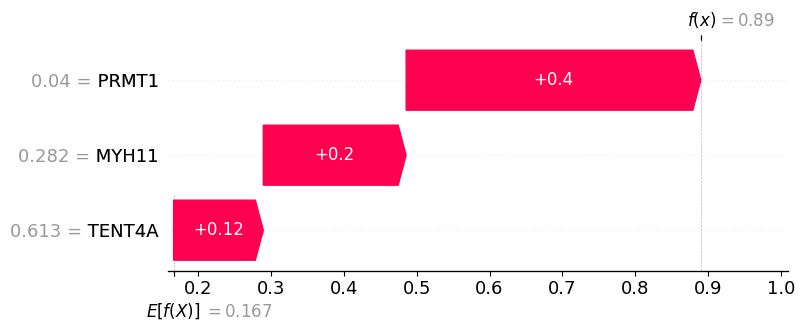

  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



Sample_ID: TCGA-YL-A9WH-nonMT — Predicted Class: 0 (p=0.063)


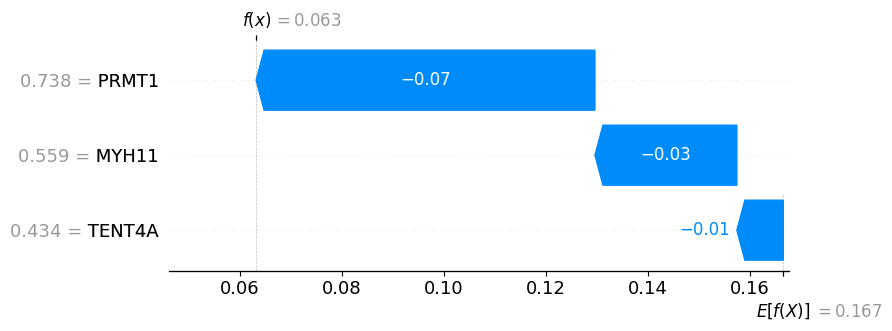

In [165]:
predict_fn_lr = make_predict_fn(best_lr)
#X_background = X_train_scaled_biomarker.copy()
explainer_lr = shap.KernelExplainer(predict_fn_lr, shap.kmeans(X_background, 10))


explain_n_predictions_scaled_auto(
    scaler=scaler_3,
    explainer=explainer_lr,
    predict_fn=predict_fn_lr,
    prediction_set=predict_set,
    feature_cols=["MYH11", "PRMT1", "TENT4A"],
    n=3,
    random_seed=10000
)



In [168]:
import joblib

# Save the model
joblib.dump(best_lr, 'best_lr.pkl')     # for logistic regression
joblib.dump(best_nn, 'best_nn.pkl')     # for neural network (e.g., MLPClassifier)
joblib.dump(scaler_3, 'scaler_3.pkl')
joblib.dump(X_background, 'X_background.pkl')


['X_background.pkl']

In [157]:
print(best_nn.classes_)  # Should show array([0, 1])


[0 1]


In [141]:
print(np.unique(y_train))


[0 1]


In [158]:
explain_n_predictions_scaled_auto(
    model=best_lr,  # a SciKeras-wrapped model
    scaler=scaler_3,
    prediction_set=predict_set,
    feature_cols=["MYH11", "PRMT1", "TENT4A"],
    n=3,
    random_seed=10000
)


TypeError: explain_n_predictions_scaled_auto() got an unexpected keyword argument 'model'

In [99]:
import joblib

# Save the model
joblib.dump(best_lr, 'best_lr.pkl')     # for logistic regression
joblib.dump(best_nn, 'best_nn.pkl')     # for neural network (e.g., MLPClassifier)
# Save scaler if used
joblib.dump(scaler_3, 'scaler.pkl')

['scaler.pkl']

In [ ]:
import pandas as pd
import numpy as np

def predict_metastasis(model, scaler, predict_set, feature_cols):
    """
    Predict metastatic probability from logistic regression model.

    Parameters:
        model : trained logistic regression model
        scaler : fitted scaler (e.g., StandardScaler)
        predict_set : DataFrame with Sample_ID and feature columns
        feature_cols : list of column names used for prediction (e.g., ["MYH11", "PRMT1", "TENT4A"])

    Returns:
        DataFrame with Sample_ID, Prediction label, and Metastatic Probability
    """

    # Select features and scale
    X_input = predict_set[feature_cols]
    X_scaled = scaler.transform(X_input)

    # Predict probabilities
    proba = model.predict_proba(X_scaled)[:, 1]  # probability of class 1 = "Metastatic"

    # Generate label
    label = np.where(proba >= 0.5, "Metastatic", "Non-Metastatic")

    # Construct result DataFrame
    result = pd.DataFrame({
        "Sample_ID": predict_set["Sample_ID"].values,
        "Prediction": label,
        "Metastatic Probability": np.round(proba, 4)
    })

    return result


In [ ]:
feature_cols = ["MYH11", "PRMT1", "TENT4A"]
result_df = predict_metastasis(best_lr, scaler_3, predict_set, feature_cols)

# Show or save
print(result_df)
# result_df.to_csv("predict_result.csv", index=False)


              Sample_ID      Prediction  Metastatic Probability
0    TCGA-EJ-7781-nonMT  Non-Metastatic                  0.0358
1            DTB-083-MT      Metastatic                  0.7922
2    TCGA-KK-A7B1-nonMT  Non-Metastatic                  0.0157
3    TCGA-EJ-A46F-nonMT  Non-Metastatic                  0.0346
4    TCGA-CH-5745-nonMT  Non-Metastatic                  0.0246
..                  ...             ...                     ...
115          DTB-149-MT      Metastatic                  0.8352
116  TCGA-V1-A8WW-nonMT  Non-Metastatic                  0.0341
117  TCGA-V1-A9Z8-nonMT  Non-Metastatic                  0.0146
118  TCGA-KK-A8I4-nonMT  Non-Metastatic                  0.0262
119          DTB-127-MT      Metastatic                  0.9520

[120 rows x 3 columns]


In [ ]:
import shap
import random
import pandas as pd
import matplotlib.pyplot as plt

def plot_shap_waterfalls(model, scaler, predict_set, feature_cols, n=3, random_seed=42):
    """
    Plots SHAP waterfall plots for `n` random samples from predict_set.
    Displays actual gene names instead of 'feature_0', etc.

    Parameters:
        model: Trained logistic regression model
        scaler: Fitted scaler used during model training
        predict_set: DataFrame with Sample_ID and selected features
        feature_cols: List of feature names used in training (e.g., ["MYH11", "PRMT1", "TENT4A"])
        n: Number of random samples to plot
        random_seed: Seed for reproducible sampling
    """
    # Sample n random indices
    random.seed(random_seed)
    sample_indices = random.sample(range(len(predict_set)), n)

    # Get selected features and scale
    X_input = predict_set[feature_cols].iloc[sample_indices]
    X_scaled = scaler.transform(X_input)

    # Wrap scaled data back into DataFrame with correct feature names
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

    # Create SHAP explainer and values
    explainer = shap.Explainer(model, X_scaled_df)
    shap_values = explainer(X_scaled_df)

    # Plot waterfall for each sample
    for i, idx in enumerate(sample_indices):
        print(f"\nSample_ID: {predict_set.iloc[idx]['Sample_ID']}")
        shap.plots.waterfall(shap_values[i], show=True)


In [ ]:
predict_set


,Sample_ID,MYH11,PRMT1,TENT4A
88,TCGA-EJ-7781-nonMT,16.425486,10.394562,8.870025
584,DTB-083-MT,12.043522,8.612378,10.312082
189,TCGA-KK-A7B1-nonMT,16.351638,11.555936,9.015172
20,TCGA-EJ-A46F-nonMT,12.106297,12.441793,9.027366
295,TCGA-CH-5745-nonMT,16.007885,11.109117,8.955318
...,...,...,...,...
525,DTB-149-MT,9.183350,9.419459,10.242888
363,TCGA-V1-A8WW-nonMT,14.749504,11.544738,9.208840
257,TCGA-V1-A9Z8-nonMT,16.814468,11.305984,8.896228
252,TCGA-KK-A8I4-nonMT,16.379562,11.355667,9.378305


In [ ]:
X_test

,PPP5C,PSMC4,NSUN2,SEC61A2,RRAGB,STRN4,HOMER2,AKT2,PRUNE2,TENT4A,...,ZXDA,ZXDB,CHIC1,JPX,FTX,ZNF585B,ZNF260,ZNF225,ZNF234,PTOV1-AS1
88,10.058679,10.431144,10.561338,7.388504,8.259892,10.946750,13.005194,11.474045,12.945110,8.870025,...,7.637537,8.962387,8.773342,8.995338,10.217024,8.667559,9.445339,7.087160,7.751637,7.739397
584,9.305909,10.325076,10.138940,9.590514,7.479627,9.733822,11.747918,10.999758,12.584540,10.312082,...,8.079808,12.850258,9.238826,11.185770,13.002590,11.318388,11.363169,8.110165,7.383409,7.847261
189,10.561025,11.108156,10.865628,8.050814,8.368762,11.335131,12.032618,11.692814,10.850291,9.015172,...,6.417508,8.209546,8.188348,8.989148,10.107445,8.387482,9.179143,7.042939,7.928289,8.360664
20,10.102012,11.656493,10.381881,9.093145,8.014803,11.030885,12.589906,11.011576,11.053090,9.027366,...,6.015121,7.968797,7.471242,8.878973,9.295643,7.975460,8.948322,5.988803,6.400984,8.588780
295,9.968031,10.353344,10.138650,7.567261,8.411400,11.016396,12.574945,11.658071,12.624166,8.955318,...,7.310526,9.007785,8.611842,8.678098,10.594710,8.189469,9.101536,7.394993,7.695724,8.011726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,9.577077,9.173255,10.631840,9.542203,9.637069,8.906983,13.127705,10.223452,15.816928,10.242888,...,9.353935,11.702980,8.564796,10.242888,12.260533,8.913063,9.449048,7.630792,7.947644,7.797911
363,10.519748,11.453938,10.603994,8.398271,8.733667,11.825673,11.739792,11.691856,11.647746,9.208840,...,6.629662,8.173811,8.217664,8.501854,9.810439,7.912693,8.862281,6.743451,7.298913,7.988307
257,10.310426,10.878504,10.194054,8.313652,8.797699,10.854990,11.912801,11.678831,11.240952,8.896228,...,6.502177,8.142867,7.966760,9.002793,9.945112,8.428589,9.058761,6.726830,7.070350,8.381075
252,10.367046,10.708887,10.587123,8.108799,8.248850,11.250445,12.060980,11.599553,11.007526,9.378305,...,6.660052,8.224052,8.290391,8.596669,9.868784,8.120364,8.697887,6.670610,7.416641,8.081448



Sample_ID: TCGA-CH-5744-nonMT


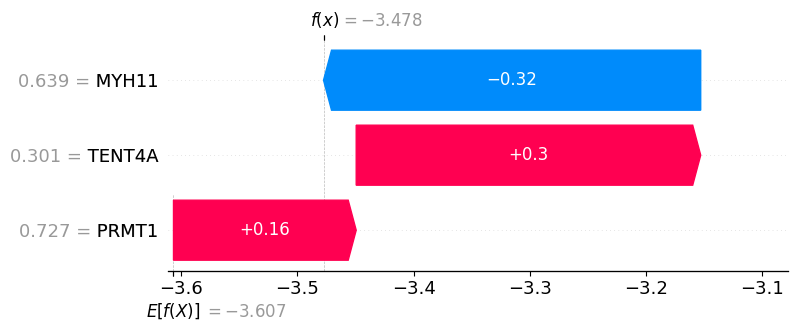


Sample_ID: TCGA-G9-6363-nonMT


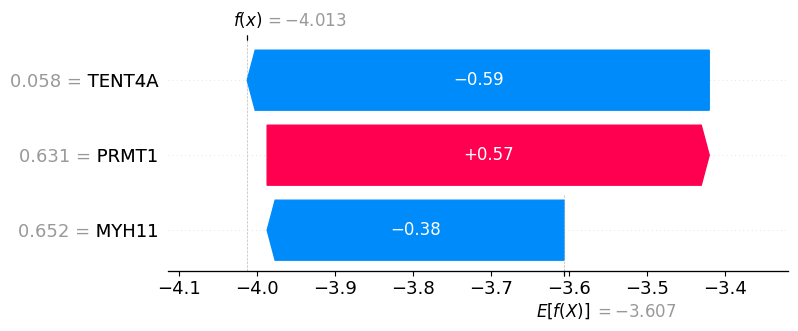


Sample_ID: TCGA-EJ-A46F-nonMT


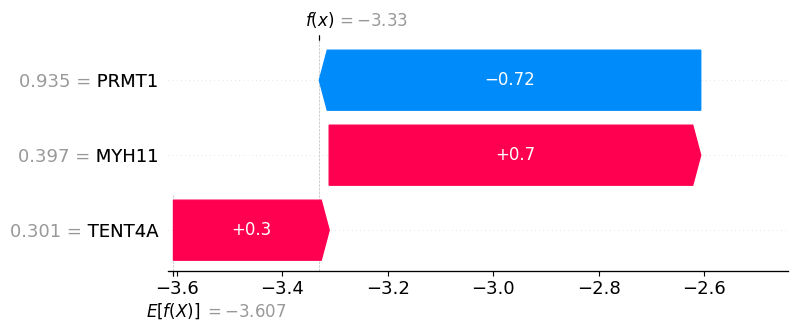

In [ ]:
feature_cols = ["MYH11", "PRMT1", "TENT4A"]
plot_shap_waterfalls(best_lr, scaler_3, predict_set, feature_cols, n=3)


In [ ]:
def explain_predict_set_shap(model, scaler, predict_set, feature_cols, n_background=10, n_plot=3):
    import shap
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Scale input
    X_input = predict_set[feature_cols]
    X_scaled = scaler.transform(X_input)
    X_df = pd.DataFrame(X_scaled, columns=feature_cols, index=predict_set.index)

    # Background data for SHAP
    background = X_df.sample(n=n_background, random_state=42)

    # Define prediction function
    def predict_fn(x):
        probs = model.predict(x)
        return probs[:, 1] if probs.ndim > 1 else probs

    # KernelExplainer
    explainer = shap.KernelExplainer(predict_fn, background)

    # Get Explanation object directly
    shap_values = explainer(X_df, nsamples=100)

    for i in range(min(n_plot, len(predict_set))):
        print(f"\nSample_ID: {predict_set.iloc[i]['Sample_ID']}")
        shap.plots.waterfall(shap_values[i], show=True)
        plt.tight_layout()
        plt.show()


In [ ]:
explain_predict_set_shap(
    model=best_nn,
    scaler=scaler_3,
    predict_set=predict_set,
    feature_cols=["MYH11", "PRMT1", "TENT4A"],
    n_plot=3
)


TypeError: KernelExplainer.__call__() got an unexpected keyword argument 'nsamples'

  0%|          | 0/120 [00:00<?, ?it/s]

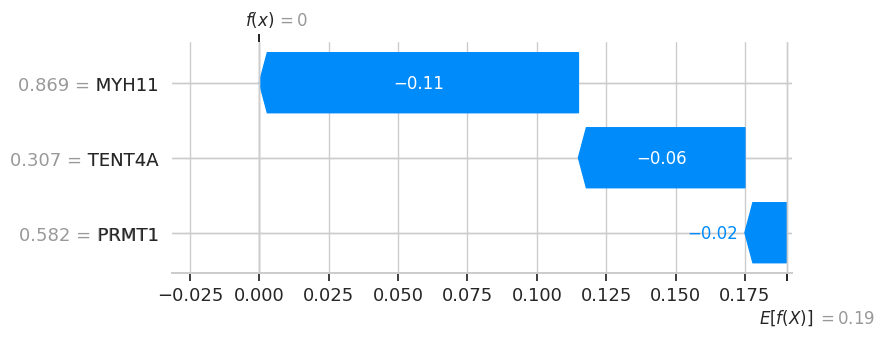

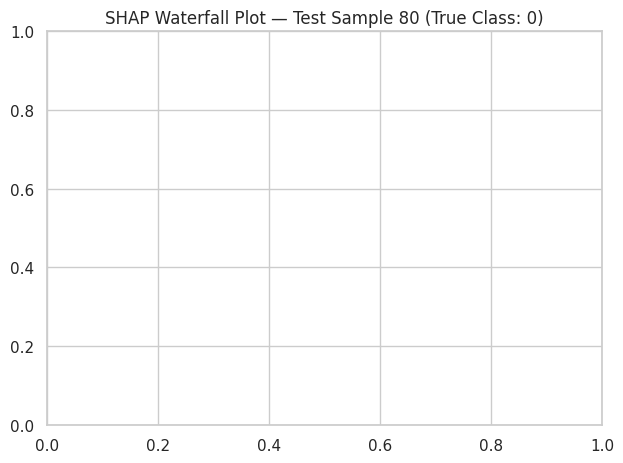

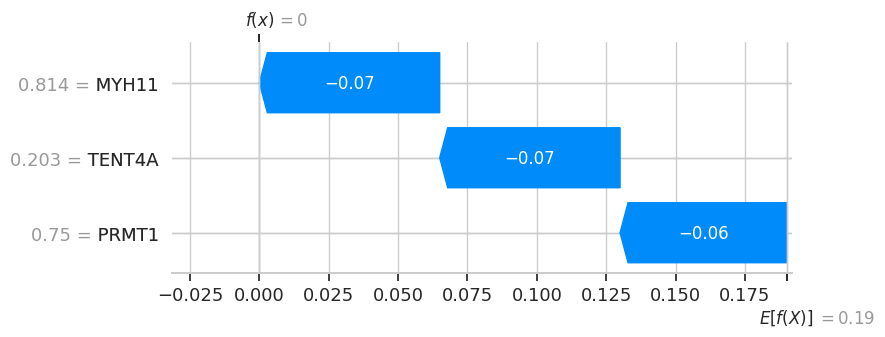

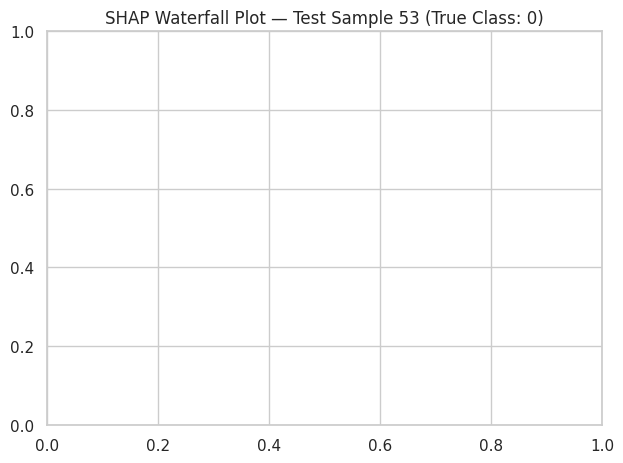

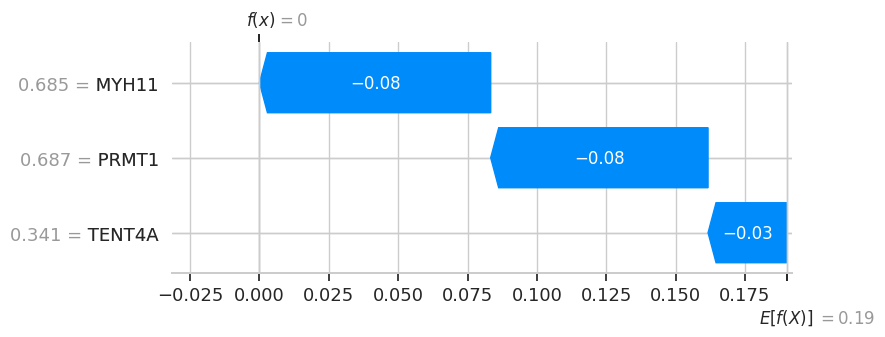

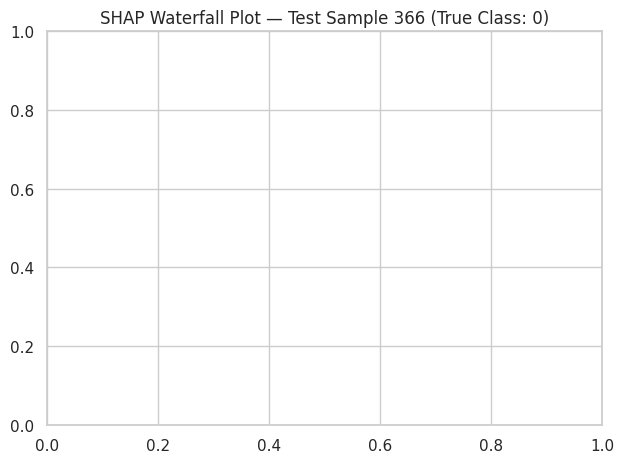

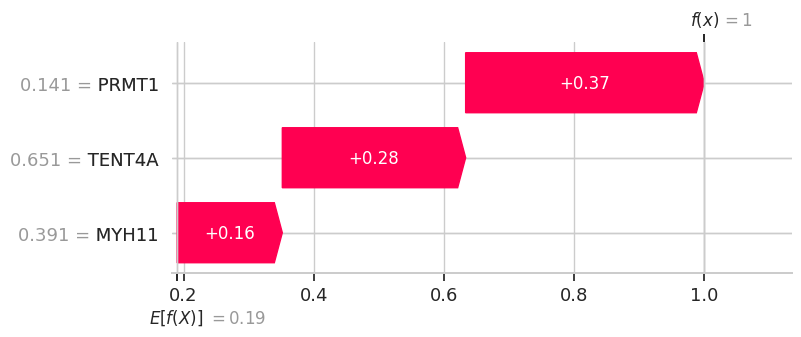

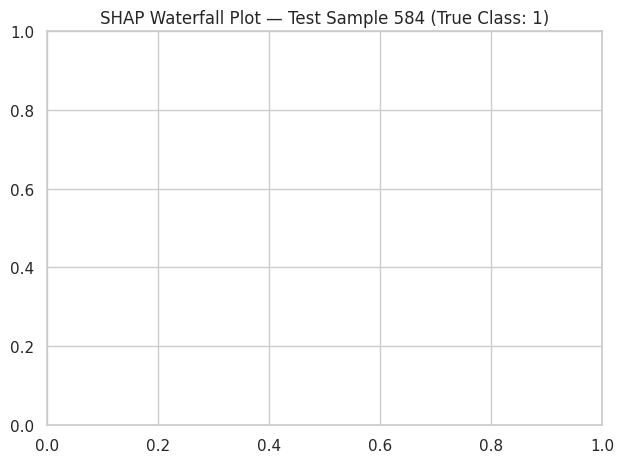

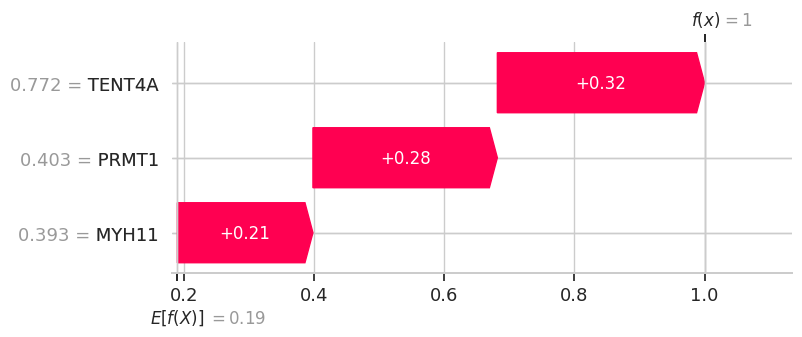

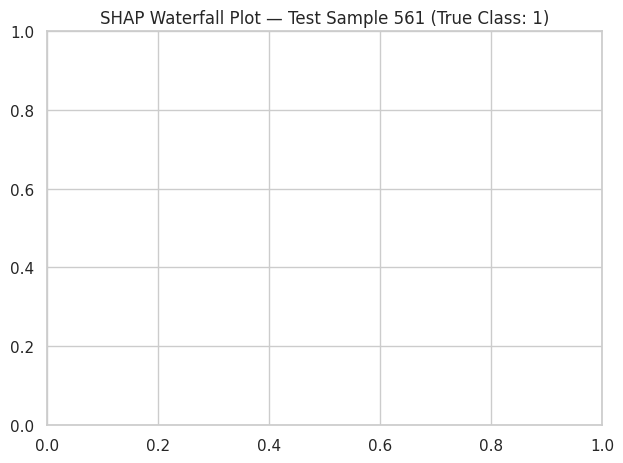

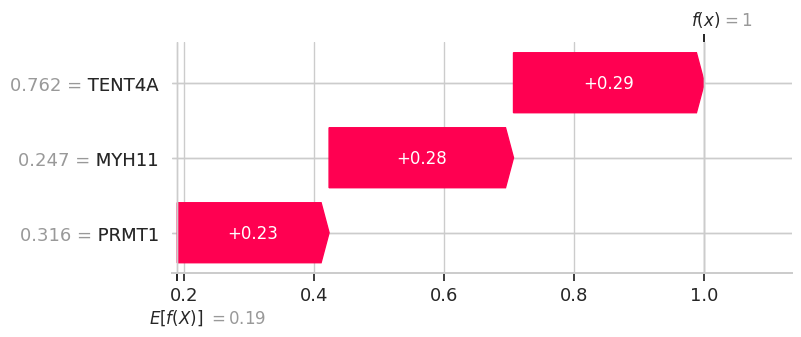

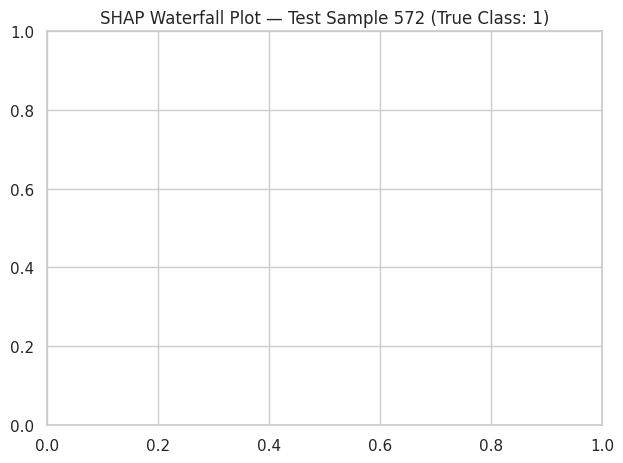

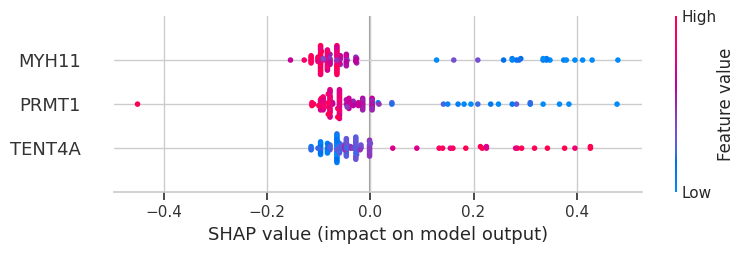

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# === 1. External Validation Function ===
def external_validation(model, X_test_scaled, y_test):
    mask = X_test_scaled.notna().all(axis=1) & y_test.notna()
    X_test_clean = X_test_scaled[mask]
    y_test_clean = y_test[mask]
    y_pred = model.predict(X_test_clean)
    if len(y_pred.shape) > 1:
        y_pred = (y_pred[:, 1] > 0.5).astype(int)
    return {
        'Accuracy': accuracy_score(y_test_clean, y_pred),
        'Precision': precision_score(y_test_clean, y_pred),
        'Recall': recall_score(y_test_clean, y_pred),
        'F1-score': f1_score(y_test_clean, y_pred),
        'Specificity': recall_score(y_test_clean, y_pred, pos_label=0)
    }

# === 2. SHAP Explanation Function ===
def explain_with_shap_kernel(model, X_background, X_explain):
    if isinstance(X_background, np.ndarray) or isinstance(X_explain, np.ndarray):
        raise ValueError("Inputs must be pandas DataFrames with gene names as columns.")

    X_background = X_background.dropna()
    X_explain = X_explain.dropna()

    def predict_fn(x):
        probs = model.predict(x)
        if len(probs.shape) > 1:
            return probs[:, 1]
        return probs

    explainer = shap.KernelExplainer(predict_fn, shap.kmeans(X_background, 10))
    shap_values = explainer.shap_values(X_explain, nsamples=100)

    return shap_values, explainer, X_explain

# === 3. Example Usage ===
gene_names = ['MYH11', 'PRMT1', 'TENT4A']  # Replace with your actual features
X_test_scaled_biomarker = pd.DataFrame(X_test_scaled_biomarker, columns=gene_names)
X_train_scaled_biomarker = pd.DataFrame(X_train_scaled_biomarker, columns=gene_names)

# Ensure index alignment
X_test_scaled_biomarker.index = y_test.index

# Step 1: Evaluate model
metrics_test_nn = external_validation(best_nn, X_test_scaled_biomarker, y_test)

# Step 2: Define SHAP background
X_background = X_train_scaled_biomarker.sample(n=100, random_state=42)

# Step 3: Explain test set
shap_values, explainer, X_explain_clean = explain_with_shap_kernel(best_nn, X_background, X_test_scaled_biomarker)

# Step 4: Match test labels to SHAP input
y_test_clean = y_test.loc[X_explain_clean.index]

# Step 5a: Plot 3 random class 0 and 3 random class 1 waterfall plots
class_0_indices = y_test_clean[y_test_clean == 0].sample(n=3, random_state=42).index
class_1_indices = y_test_clean[y_test_clean == 1].sample(n=3, random_state=42).index
selected_indices = list(class_0_indices) + list(class_1_indices)

for idx in selected_indices:
    i = X_explain_clean.index.get_loc(idx)
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_explain_clean.iloc[i].values,
        feature_names=X_explain_clean.columns.tolist()
    ))
    plt.title(f"SHAP Waterfall Plot — Test Sample {idx} (True Class: {y_test_clean.loc[idx]})")
    plt.tight_layout()
    plt.show()

# Step 5b: Beeswarm summary plot
shap.summary_plot(shap_values, X_explain_clean)


In [ ]:
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# === 2. SHAP Explanation Function ===
def explain_with_shap(model, X_background, X_explain, feature_names):
    """Use SHAP unified Explainer to explain predictions."""

    # Define prediction function for SHAP
    def predict_fn(x):
        probs = model.predict(x)
        if len(probs.shape) > 1:
            return probs[:, 1]  # For binary classifier
        return probs

    # Wrap DataFrame with gene names
    X_background_df = pd.DataFrame(X_background, columns=feature_names)
    X_explain_df = pd.DataFrame(X_explain, columns=feature_names)

    # SHAP Explainer
    explainer = shap.Explainer(predict_fn, X_background_df)
    shap_values = explainer(X_explain_df)

    # Example: visualize SHAP waterfall for first sample
    shap.plots.waterfall(shap_values[0], max_display=10)

    return shap_values

# === 3. Full Pipeline Usage Example ===

# Assume: best_nn, X_train_scaled_biomarker, X_test_scaled_biomarker, y_test already defined
# Gene names must match the number of features
gene_names = ['MYH11', 'PRMT1', 'TENT4A']  # Use the correct gene list matching feature order

# Step 1: Evaluate model on external test set
metrics_test_nn = external_validation(best_nn, X_test_scaled_biomarker, y_test)

# Step 2: Define SHAP background from training set
X_background = pd.DataFrame(X_train_scaled_biomarker, columns=gene_names).sample(100, random_state=42)

# Step 3: Use all test data for SHAP explanation
X_test_df = pd.DataFrame(X_test_scaled_biomarker, columns=gene_names)

# Step 4: Run SHAP
shap_values = explain_with_shap(best_nn, X_background, X_test_df, gene_names)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import shap
import matplotlib.pyplot as plt

# === 1. External Validation Function ===
def external_validation(model, X_test_scaled, y_test):
    """Evaluates the best model on an external test set and displays classification metrics."""

    # Drop rows with NaNs in either X or y
    mask = X_test_scaled.notna().all(axis=1) & y_test.notna()
    X_test_clean = X_test_scaled[mask]
    y_test_clean = y_test[mask]

    if len(X_test_clean) == 0:
        raise ValueError("No valid data left after removing NaNs.")

    y_pred = model.predict(X_test_clean)
    acc = accuracy_score(y_test_clean, y_pred)
    precision = precision_score(y_test_clean, y_pred, pos_label=1)
    recall = recall_score(y_test_clean, y_pred, pos_label=1)
    f1 = f1_score(y_test_clean, y_pred, pos_label=1)

    cm = confusion_matrix(y_test_clean, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    # Create summary DataFrame
    metrics = pd.DataFrame({
        "Accuracy": [acc],
        "Precision": [precision],
        "Recall": [recall],
        "F1-score": [f1],
        "Specificity": [specificity]
    }, index=["Class 1"])

    print("=== External Validation Metrics (Class 1) ===")
    print(metrics.round(4))
    return metrics


# === 2. SHAP Explanation Function ===
def explain_with_shap_kernel(model, X_background, X_explain):
    """Use SHAP KernelExplainer to explain predictions for all samples."""

    if isinstance(X_background, np.ndarray):
        raise ValueError("X_background must be a pandas DataFrame with gene names as columns.")
    if isinstance(X_explain, np.ndarray):
        raise ValueError("X_explain must be a pandas DataFrame with gene names as columns.")

    # Drop any NaNs to avoid SHAP errors
    X_background = X_background.dropna()
    X_explain = X_explain.dropna()

    if X_background.empty or X_explain.empty:
        raise ValueError("X_background or X_explain is empty after dropping NaNs.")

    def predict_fn(x):
        probs = model.predict(x)
        if len(probs.shape) > 1:
            return probs[:, 1]
        return probs

    # SHAP KernelExplainer
    explainer = shap.KernelExplainer(predict_fn, shap.kmeans(X_background, 10))
    shap_values = explainer.shap_values(X_explain, nsamples=100)

    return shap_values, explainer, X_explain


# === 3. Example Usage ===

# Step 0: Gene/Feature names
gene_names = ['MYH11', 'PRMT1', 'TENT4A']  # Replace with your actual gene names

# Step 1: Ensure DataFrame format with proper column names
X_test_scaled_biomarker = pd.DataFrame(X_test_scaled_biomarker, columns=gene_names)
X_train_scaled_biomarker = pd.DataFrame(X_train_scaled_biomarker, columns=gene_names)

# Step 2: Evaluate model on test set
metrics_test_nn = external_validation(best_nn, X_test_scaled_biomarker, y_test)

# Step 3: Define SHAP background (subset of train set, 100 samples)
X_background = X_train_scaled_biomarker.sample(n=100, random_state=42)

# Step 4: Explain all test samples
shap_values, explainer, X_explain_clean = explain_with_shap_kernel(best_nn, X_background, X_test_scaled_biomarker)

# Step 5: SHAP Visualization

# (a) Waterfall plot for first test sample
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_explain_clean.iloc[0].values,
    feature_names=X_explain_clean.columns
))

# (b) Summary plot for all test samples
shap.summary_plot(shap_values, X_explain_clean)


In [ ]:
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# === 2. SHAP Explanation Function ===
def explain_with_shap(model, X_background, X_explain):
    """Use SHAP unified Explainer to explain predictions."""

    # Define prediction function for SHAP
    def predict_fn(x):
        probs = model.predict(x)
        if len(probs.shape) > 1:
            return probs[:, 1]  # binary classifier
        return probs

    # Use SHAP Explainer (automatically chooses the right method)
    explainer = shap.Explainer(predict_fn, X_background)
    shap_values = explainer(X_explain)

    # Visualize explanation for the first sample
    shap.plots.waterfall(shap_values[0])

    return shap_values


# === 3. Full Pipeline Usage Example ===

# Assume these are already defined and fitted earlier in your session
# best_nn = your trained model (e.g., sklearn MLPClassifier)
# X_train_scaled_biomarker = training features (scaled, as NumPy or DataFrame)
# X_test_scaled_biomarker = test features (scaled, as NumPy or DataFrame)
# y_test = test labels (binary)
gene_names = ['MYH11', 'PRMT1', 'TENT4A']
# Step 1: Evaluate on external test set
metrics_test_nn = external_validation(best_nn, X_test_scaled_biomarker, y_test)

# Step 2: Define SHAP background (subset of training set)
X_background = pd.DataFrame(X_train_scaled_biomarker, columns=[f"Feature_{i}" for i in range(X_train_scaled_biomarker.shape[1])]).sample(100, random_state=42)
X_test_scaled_biomarker = pd.DataFrame(X_test_scaled_biomarker, columns=X_background.columns)

# Step 3: Select samples from test set to explain
X_explain = X_test_scaled_biomarker.iloc[:50]  # explain first 50 test samples

# Step 4: Run SHAP and visualize
shap_values = explain_with_shap(best_nn, X_background, X_explain)


In [ ]:
print(X_test_scaled_biomarker.isnull().sum())


In [ ]:
print(X_background.isnull().sum())
print(X_explain.isnull().sum())


# Export Model

In [ ]:
import joblib

# Save the best model
joblib.dump(best_lr, "best_lr_model.pkl")
print("best_lr saved as best_lr_model.pkl")

joblib.dump(best_svm, "best_svm_model.pkl")
print("best_svm saved as best_svm_model.pk")

joblib.dump(best_nn, "best_nn_model.pkl")
print("best_nn saved as best_nn_model.pk")


# Save workspace

In [ ]:
!pip install dill


In [ ]:
#save
import dill
filename = "workspace.pkl"

# Save all variables
with open(filename, "wb") as f:
    dill.dump_session(f)

print("Workspace saved as workspace.pkl")


In [ ]:

import dill

# Load saved workspace
with open("workspace.pkl", "rb") as f:
    dill.load_session(f)

print("Workspace restored!")


<ipython-input-426-2117756524>:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


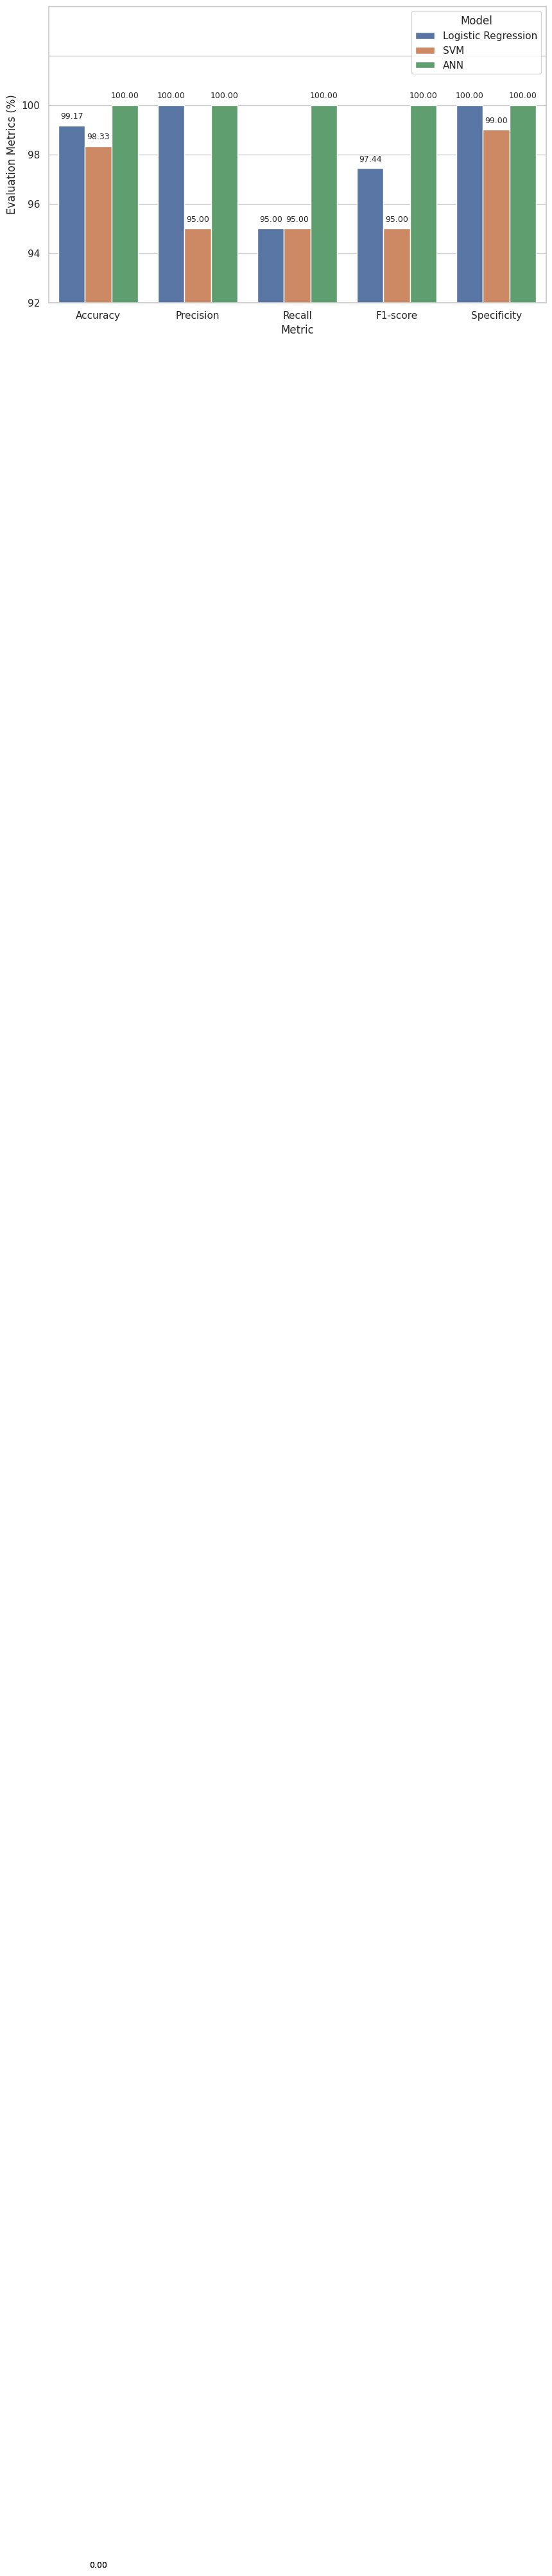

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the data
data = {
    "Model": ["Logistic Regression", "SVM", "ANN"],
    "Accuracy": [0.991667, 0.983333, 1.0],
    "Precision": [1.0, 0.95, 1.0],
    "Recall": [0.95, 0.95, 1.0],
    "F1-score": [0.974359, 0.95, 1.0],
    "Specificity": [1.0, 0.99, 1.0]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Reshape DataFrame to long format
df_long = df.melt(id_vars="Model", var_name="Metric", value_name="Value")
df_long["Value_pct"] = df_long["Value"] * 100

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

ax = sns.barplot(
    data=df_long,
    x="Metric",
    y="Value_pct",
    hue="Model"
)

# Add value labels
for bar in ax.patches:
    height = bar.get_height()
    bar_x = bar.get_x() + bar.get_width() / 2
    ax.text(bar_x, height + 0.2, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

# Set y-axis limit
plt.ylim(92, 104)
plt.ylabel("Evaluation Metrics (%)")

# Hide y-tick labels > 100
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.set_yticklabels([f"{tick:.0f}" if tick <= 100 else "" for tick in ticks])

# Finalize plot
plt.legend(title="Model", loc="upper right")
plt.tight_layout()
plt.show()
